<a href="https://colab.research.google.com/github/Geekrish26/Yulu---Hypothesis-Testing-Case-study/blob/main/Yulu_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement :-
Yulu has been facing a recent decline in revenues, indicating possible fluctuations in the demand for its shared electric cycles. To address this challenge, the objective of this case study is to analyze historical ride data to identify the key factors influencing electric cycle demand in the Indian market. Specifically, the study examines how working days, seasons, and weather conditions impact the total number of rentals (count) and evaluates whether these variables significantly explain variations in user demand. Through exploratory data analysis and statistical hypothesis testing, the analysis aims to generate data-driven insights that can help Yulu optimize operations, improve demand forecasting, and support strategic decision-making under business uncertainty.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import kstest

In [2]:
df = pd.read_csv('bike_sharing.csv')
df.sample(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
8054,2012-06-15 23:00:00,2,0,1,1,25.42,31.060,53,16.9979,46,176,222
952,2011-03-04 03:00:00,1,0,1,2,7.38,8.335,74,16.9979,0,1,1
4253,2011-10-09 06:00:00,4,0,0,1,18.04,21.970,88,0.0000,7,14,21
3800,2011-09-09 08:00:00,3,0,1,3,25.42,27.275,94,11.0014,12,276,288
8504,2012-07-15 17:00:00,3,0,0,1,32.80,38.635,59,32.9975,122,314,436
7411,2012-05-08 04:00:00,2,0,1,2,21.32,25.000,68,22.0028,0,5,5
6487,2012-03-07 13:00:00,1,0,1,1,20.50,24.240,34,27.9993,26,179,205
402,2011-01-18 18:00:00,1,0,1,2,9.02,11.365,80,11.0014,1,132,133
7222,2012-04-19 07:00:00,2,0,1,2,16.40,20.455,82,8.9981,15,391,406
7703,2012-06-01 08:00:00,2,0,1,2,26.24,28.790,89,12.9980,19,675,694


In [3]:
df.shape

(10886, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [5]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [6]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
10881,False
10882,False
10883,False
10884,False


In [7]:
for col in ['season','holiday','workingday','weather']:
  if col in df.columns:
    df[col] = df[col].astype('category')

In [8]:
import pandas as pd

if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])

    df['hour'] = df['datetime'].dt.hour.astype(int)
    df['day'] = df['datetime'].dt.day.astype(int)
    df['month'] = df['datetime'].dt.month.astype(int)
    df['weekday'] = df['datetime'].dt.weekday.astype(int)

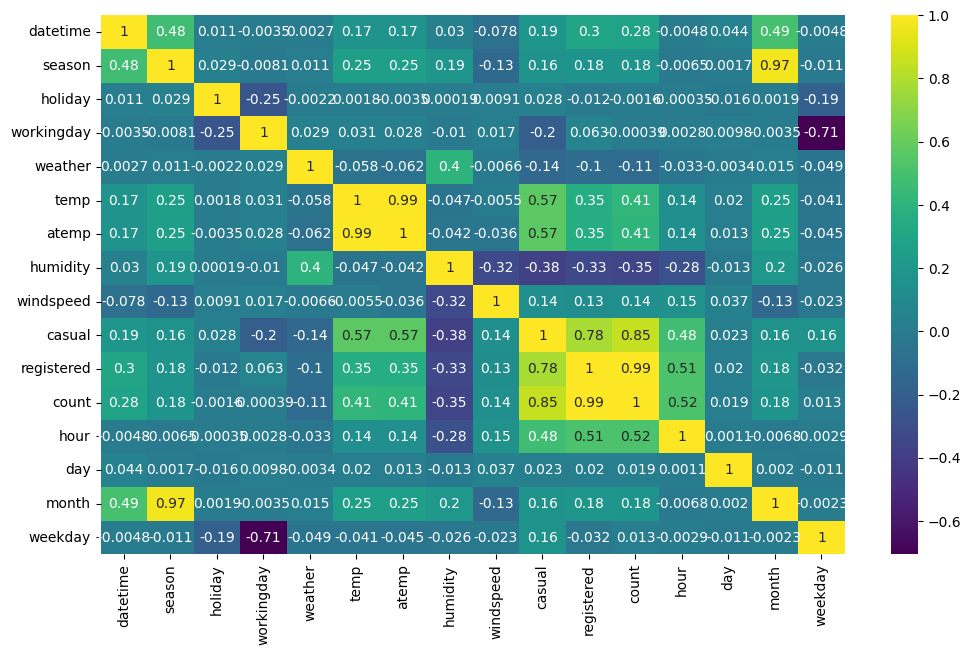

In [9]:
plt.figure(figsize=(12,7))
sbn.heatmap(df.corr(method = 'spearman'), annot= True, cmap='viridis')
plt.show()

In [10]:
# we will drop highly correlated columns -
dfn = df.drop(columns=['casual','registered','atemp'])

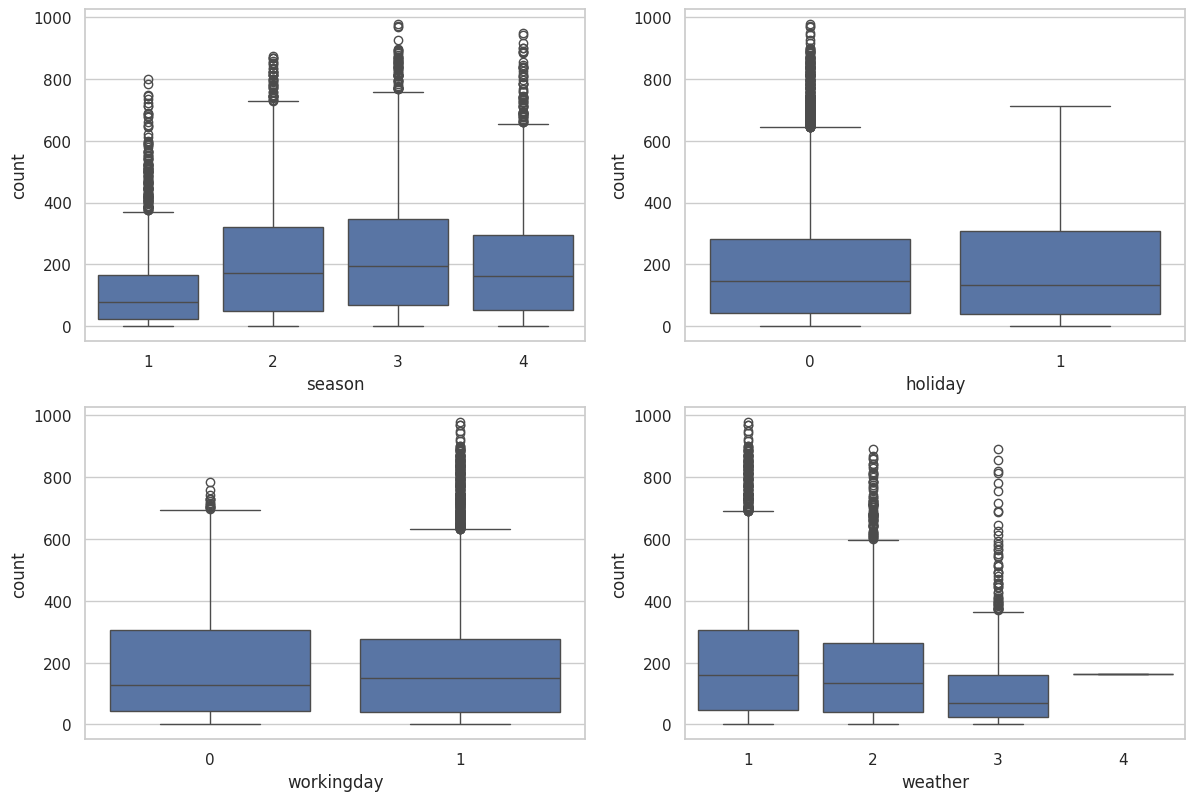

In [11]:
# outlier detection using boxplot -
col_list = ['season', 'holiday', 'workingday', 'weather']
sbn.set(style= "whitegrid")
fig= plt.figure(figsize=(8,25))
fig.subplots_adjust(right=1.5)

for plot in range(1, len(col_list)+1):
  plt.subplot(5,2,plot)
  sbn.boxplot(x=dfn[col_list[plot-1]],y=dfn['count'])

plt.show()


/tmp/ipykernel_13450/748722816.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(dfn['count'],bins=10)


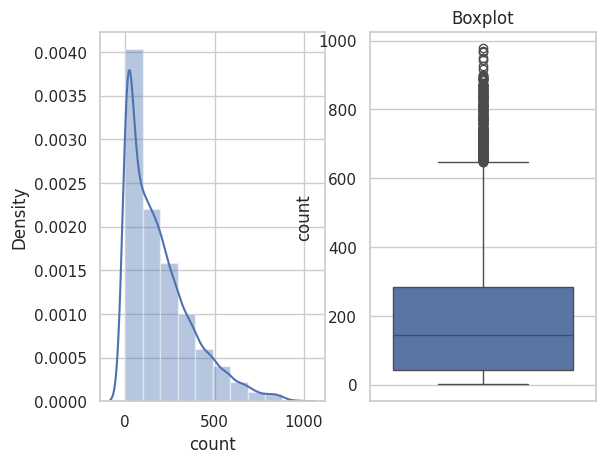

In [12]:
# checking for distribution of 'count' column -
#plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sbn.distplot(dfn['count'],bins=10)

plt.subplot(1,2,2)
sbn.boxplot(y=dfn['count'])
plt.title('Boxplot')

plt.show()

/tmp/ipykernel_13450/3616639365.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(np.log(dfn['count']), bins=10)


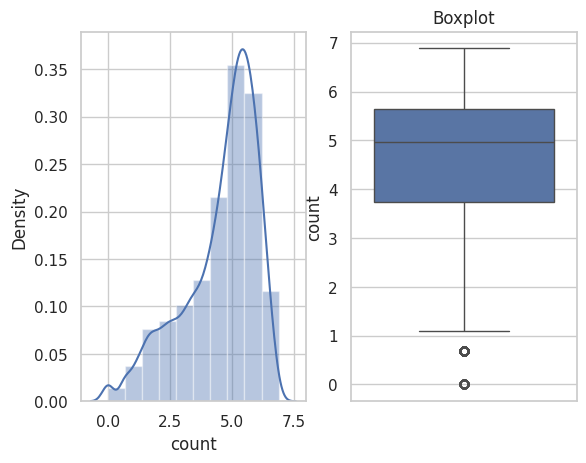

In [13]:
#checking distribution after applying log transformation -
plt.subplot(1,2,1)
sbn.distplot(np.log(dfn['count']), bins=10)

plt.subplot(1, 2, 2)
sbn.boxplot(y=np.log(dfn['count']))
plt.title('Boxplot')

plt.show()


Aggregating the total no. of bike rides beased on the given factors -

In [14]:
# 1. Workingday
pd.DataFrame(dfn.groupby('workingday')['count'].describe())

/tmp/ipykernel_13450/2638398587.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.DataFrame(dfn.groupby('workingday')['count'].describe())


,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,3474.0,188.506621,173.724015,1.0,44.0,128.0,304.0,783.0
1,7412.0,193.011873,184.513659,1.0,41.0,151.0,277.0,977.0


In [15]:
# 2. Holiday
pd.DataFrame(dfn.groupby('holiday')['count'].describe())

/tmp/ipykernel_13450/2041242473.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.DataFrame(dfn.groupby('holiday')['count'].describe())


,count,mean,std,min,25%,50%,75%,max
holiday,,,,,,,,
0,10575.0,191.741655,181.513131,1.0,43.0,145.0,283.0,977.0
1,311.0,185.877814,168.300531,1.0,38.5,133.0,308.0,712.0


In [16]:
# 3. Season
pd.DataFrame(dfn.groupby('season')['count'].describe())

/tmp/ipykernel_13450/3992635455.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.DataFrame(dfn.groupby('season')['count'].describe())


,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [17]:
#4. Weather
pd.DataFrame(dfn.groupby('weather')['count'].describe())

/tmp/ipykernel_13450/2571644027.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.DataFrame(dfn.groupby('weather')['count'].describe())


,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
4,1.0,164.000000,NaN,164.0,164.0,164.0,164.0,164.0


Define the null and alternate hypothesis

Ho : The demand of bikes on weekdays is greater or similar to the demand of bikes on weekend.

Ha: The demand of bikes on weekdays is less than demand of bikes on holiday

Select an appropriate test

In [18]:
weekday = dfn[dfn['workingday']==1]['count'].sample(2999)
weekend = dfn[dfn['workingday']==0]['count'].sample(2999)
print(round(weekday.std(),2))
print(round(weekend.std(),2))

185.4
173.77


As the sample SD is different, the population SD can be assumed to be different.

This is a one-tailed test concerning two population mean from two independent population,
As the population SD are unknown, the two sample independent t-test will be the appropriate test for this problem.

As given in the problemstatement, we select alpha = 0.05.

In [19]:
alpha = 0.05

Calculate the p-value

In [20]:
def result(p_value, alpha):
  if p_value < alpha:
    print('Reject the null hypothesis')
  else:
    print('Fail to reject the null hypothesis')

In [21]:
test_stat, p_value = ttest_ind(weekday, weekend, equal_var = False, alternative = 'less')
print(p_value)

result(p_value, alpha)

0.8248452941445961
Fail to reject the null hypothesis


Observation: Since the p_value is greater than the 5% significance level, we fail to reject the null hypothesis. Hence we have enough statistical evidence to say that the average no. of bike rides during weekdays is greater than or equal to those on weekends.

Is the demand of bicycles on rent same for different weather condition ?

Define the null and alternate hypothesis

Ho: The average no. of bikes rides in different weather conditions are equal.

Ha: The average no. of bike rides in different weather condition are not equal.

In [22]:
dfn = dfn[~(dfn['weather']==4)]

In [23]:
w1= dfn[dfn['weather']==1]['count'].sample(750)
w2= dfn[dfn['weather']==2]['count'].sample(750)
w3= dfn[dfn['weather']==3]['count'].sample(750)

In [24]:
dfn.groupby('weather')['count'].describe()

/tmp/ipykernel_13450/11528030.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfn.groupby('weather')['count'].describe()


,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shapiro-Wilk's test -

We will test the null hypothesis

Ho: Count follows normal ditribution

Ha: Count doesn't follow normal distribution

In [25]:
# Assumption 1: Normality

w,p_value = shapiro(dfn['count'].sample(4999))
print(p_value)

result(p_value, alpha)

4.446633421470982e-53
Reject the null hypothesis


Levene's test:

We will test the null hypothesis

Ho: All the count variance are equal

Ha: At least one variance is different from the rest.

In [26]:
# Assumption 2: Homogeneity of Variance

stat, p_value = levene(w1,w2,w3)
print(p_value)

result(p_value,alpha)

1.0651939060826922e-16
Reject the null hypothesis


Central Limit Theorm-

/tmp/ipykernel_13450/1267102690.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(dfn['count'].sample(4999))


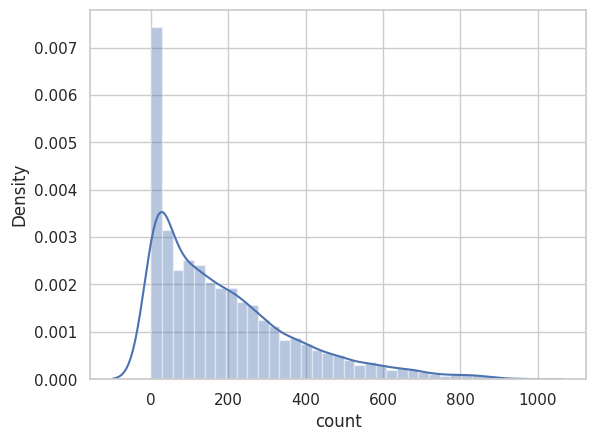

In [27]:
# To check for normality
# Method 1: Using a Histogram

sbn.distplot(dfn['count'].sample(4999))
plt.show()

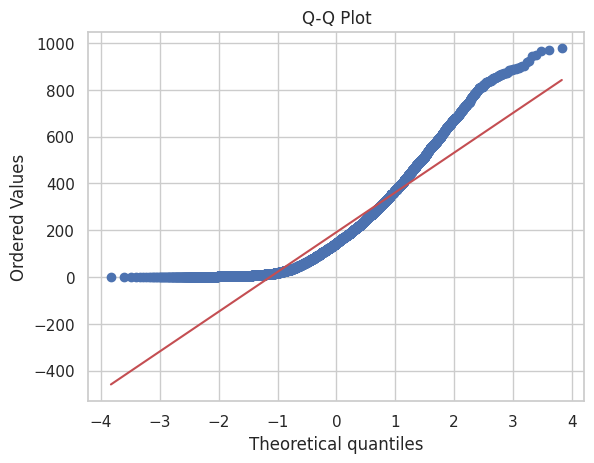

In [28]:
# Method 2: Using a Q-Q plot
stats.probplot(dfn['count'], dist='norm',fit= True, plot=plt)
plt.title('Q-Q Plot')
plt.show()

In [29]:
#Method 3: Check skewness & kurtosis
# Skewness should be close to 0 and kurtosis should be close to 3
print(dfn['count'].skew())
print(dfn['count'].kurtosis())


1.2419715082388256
1.2996467347537868


In [30]:
# Method 4: Using KS Test to compare with the Gaussian CDF
zs = (dfn['count']-dfn['count'].mean())/dfn['count'].std()
stats.kstest(zs, stats.norm.cdf)

KstestResult(statistic=np.float64(0.146394521560417), pvalue=np.float64(4.5881688628522135e-204), statistic_location=np.float64(-1.0520229003098525), statistic_sign=np.int8(-1))

To check for Homogenity of Variance -

In [31]:
#Method 1:
print(w1.var(), w2.var(), w3.var())

36015.71357365372 29239.21798664888 19928.383282599014


The Significance level is already set to 5% i.e. 0.05

Calc p_value

In [32]:
#One-way ANOVA-
test_stat, p_value = f_oneway(w1,w2,w3)
print(p_value)

1.7515039414283093e-22


Is the demand of bikes on rent same for different seasons ?

Ho: The average no. of bike rides in different seasons are equal.

Ha: The average no. of bikes rides in different seasons are not equal.

In [33]:
s1= dfn[dfn['season']==1]['count'].sample(1000)
s2= dfn[dfn['season']==2]['count'].sample(1000)
s3= dfn[dfn['season']==3]['count'].sample(1000)
s4= dfn[dfn['season']==4]['count'].sample(1000)

In [34]:
dfn.groupby('season')['count'].describe()

/tmp/ipykernel_13450/936539160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfn.groupby('season')['count'].describe()


,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2685.0,116.325512,125.293931,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


The significance level (alpha) is already 0.05

In [35]:
# Calc the p_value
test_stat, p_value = f_oneway(s1,s2,s3,s4)
print(p_value)

3.5354389407565345e-56


Are the weather conditions significantly different during different seasons

Ho: Weather conditions are independent of the seasons.

Ha: Weather condition depends on the ongoing seasons.

In [36]:
dfn['season_enc'] = dfn['season'].astype('category')
dfn['weather_enc'] = dfn['weather'].astype('category')

In [37]:
contigency= pd.crosstab(dfn.season_enc, dfn.weather_enc)
contigency

weather_enc,1,2,3
season_enc,,,
1,1759,715,211
2,1801,708,224
3,1930,604,199
4,1702,807,225


<Axes: xlabel='season_enc'>

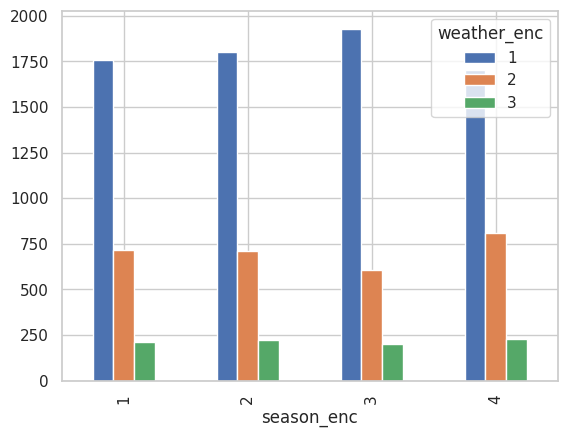

In [38]:
contigency.plot(kind='bar')

The alpha is already set to 0.05

In [41]:
#Calculate the p-value
chi2, pval,dof, exp_freq = chi2_contingency(contigency, correction = False)
print(pval)

result(pval, alpha)


2.8260014509929343e-08
Reject the null hypothesis


Observation: Since the p_value is less than the 5% significance level, we reject the null hypothesis. Hence, we have enough statistical evidence to say that the weather conditions are indeoendent on the ongoing season.

### Insights and Recommendations

#### EDA Based Insights

* Total **10,886 rows** were present in the dataset.
* No **missing values** or **duplicate records** were found.
* **Temperature (`temp`) and feeling temperature (`atemp`)** were highly correlated → `atemp` was dropped to avoid multicollinearity.
* **Target variable (`count`)** showed high correlation with `casual` and `registered` → both columns were dropped to prevent data leakage and multicollinearity.
* **Outliers** were detected in the `count` column.

#### Insights from Hypothesis Testing

* Bike rentals on **weekdays** are higher compared to weekends.
* Bike rentals on **working (non-holiday) days** are higher than on holidays.
* Bicycle demand varies significantly across **different weather conditions**.
* Bicycle demand differs across **seasons**.
* **Weather conditions are dependent on season**, indicating a relationship between the two variables.
